# CPM organoid demo in 2D

This notebook builds a small tissue of **four** cell types with differential
adhesion, runs it through the Rust `cpm` simulator, and renders the **actual
lattice** with real cell shapes and boundaries, pixel for pixel, as they self-organise into distinct domains over time. This is
a four-population extension of the classic Steinberg differential adhesion
hypothesis (DAH) demo.

**On parameters, since they matter for whether this looks realistic or
not**: CPM dynamics run at a fixed temperature (T=1, and is not adjustable. It's
an exact degeneracy with the adhesion/stiffness scales, so this project
never exposes it). There are two failure modes to avoid:

- Stiff `lambda_volume`/`lambda_interface` (values tuned for calibrating a
  single cell's target volume) produce an essentially **frozen, glassy
  tissue**.
- Too many, too-small cells sort extremely slowly even with good adhesion
  contrast (CPM cell sorting is a genuinely slow, sometimes only partially-
  complete process in 2D).

The values below are tuned to visibly sort within about a minute of MCS
time on a small grid: fewer, larger cells, softer volume/interface
stiffness, and a real adhesion hierarchy. 

Requires the package built and installed (from the repo root):

```bash
maturin develop --release
```


In [1]:
import warnings

import cpm
import matplotlib.pyplot as plt
import numpy as np

## Build the tissue

We have four cell types (stem, progenitor, differentiated, and surface). Each type sticks strongly to itself ($J \approx 0.05$) and repels all other types ($J \approx 4.0$). They all have a moderate, uniform affinity for medium ($J \approx 2.5$), so no single type gets forced to the inside or outside.This setup gives you a four-way sort where each cell type forms its own clusters, rather than a fully nested organoid structure. Real organoids usually layer up with stem cells on the inside and differentiated cells on the outside. If you want to push for that kind of nested layering, try increasing J[type][medium] step-by-step from stem up to surface.

In [2]:
GRID = 70

sim = cpm.CPM(
    grid=(GRID, GRID),
    boundary="fixed",
    seed=11,
    copy_neighborhood="von_neumann",
    connectivity_neighborhood="von_neumann",
)

CELL_TYPES = ["stem", "progenitor", "differentiated", "surface"]
for name in CELL_TYPES:
    sim.register_cell_type(
        name=name,
        target_volume=110,
        target_interface=135,
        lambda_volume=1.2,
        lambda_interface=0.7,
    )
for name in CELL_TYPES:
    sim.add_cells(cell_type=name, n=6)

# Rows/cols: 0 = medium, then stem, progenitor, differentiated, surface (in
# the order added above). Strong homotypic cohesion (diagonal), strong
# heterotypic repulsion (off-diagonal among cell types), moderate uniform
# medium adhesion.
sim.set_adhesion(
    [
        [0.0, 2.5, 2.5, 2.5, 2.5],
        [2.5, 0.05, 4.0, 4.0, 4.0],
        [2.5, 4.0, 0.05, 4.0, 4.0],
        [2.5, 4.0, 4.0, 0.05, 4.0],
        [2.5, 4.0, 4.0, 4.0, 0.05],
    ]
)


warnings.filterwarnings("ignore", category=cpm.CPMInitializationWarning)

## Running the simulation

We explicitly set burn_in_mcs=0. While burn-in normally discards the initial relaxation phase during real inference, that transient phase (cells scattering, growing, and sorting) is the main process we want to observe here. At this grid size, 60,000 MCS takes about 8 seconds in release mode. Most sorting occurs within the first 40,000–50,000 steps before plateauing into real convergence.

Setting include_lattice=True instructs run() to capture the full cell-id grid at each sample. This is disabled by default to save memory, but useful for debugging and visualization (see Sample.lattice in crates/cpm-core/src/output.rs).

The simulation will return result.status.kind == "Degenerate". In inference runs, this flag warns that the tissue has merged into a single connected mass. For a compact organoid demo, this simply confirms the organoid remained intact and is completely expected.

In [3]:
result = sim.run(
    burn_in_mcs=0, readout_mcs=400000, sampling_interval_mcs=2500, include_lattice=True
)

print("status:", result.status.kind)
print("derived_phi:", round(result.metadata.derived_phi, 3))
print("frames captured:", len(result.samples))
print("cell types:", result.cell_type_names)

status: Degenerate
derived_phi: 0.537
frames captured: 160
cell types: ['stem', 'progenitor', 'differentiated', 'surface']


## Sanity check: is it actually sorting?

To verify sorting behavior, track the homotypic contact fraction (the share of cell-cell boundaries shared by cells of the same type, calculated from sample.contact). With four roughly equal populations, a randomly mixed initial state starts around 0.3. As sorting progresses, this value should climb and eventually level off into a stable configuration.

Two additional sanity checks:

* **Active motility**: Ensure lattice sites continue updating between samples.

* **Energy relaxation**: Confirm the total energy drops during sorting before plateauing.

In [4]:
def homotypic_fraction(sample, type_index):
    contact = sample.contact
    n = contact.shape[0]
    same = diff = 0
    for a in range(1, n):
        for b in range(a + 1, n):
            weight = int(contact[a, b])
            if weight == 0:
                continue
            if type_index[a - 1] == type_index[b - 1]:
                same += weight
            else:
                diff += weight
    return same / (same + diff) if (same + diff) else float("nan")


# prev_lattice = None
# for sample in result.samples:
#     changed = "  --" if prev_lattice is None else f"{(sample.lattice != prev_lattice).sum():4d}"
#     frac = homotypic_fraction(sample, result.cell_type_index)
#     print(
#         f"mcs={sample.mcs:6d}   sites changed since last sample: {changed}   "
#         f"energy={sample.conservative_energy:8.1f}   homotypic_fraction={frac:.3f}"
#     )
#     prev_lattice = sample.lattice

A rise from the mixed baseline up to ~0.45–0.5 that levels off confirms genuine domain sorting. If it stayed flat, the cells would just be jiggling in place; if it hit 1.0, they would be completely segregated (which takes much longer to achieve).

### Rendering the lattice

Here are two ways to look at the exact same data:

* By cell: Gives every individual cell its own stable color so you can track how real cell shapes stretch and move over time.

* By type: Colors cells by their population group, making the overall sorting pattern easy to spot immediately.

Both options render sample.lattice pixel-for-pixel with no approximations.

In [5]:
n_ids = len(result.cell_type_index)

# A stable, distinct colour per cell id (medium = white), reused across
# every frame so a given cell keeps its colour as it moves.
palette = plt.get_cmap("tab20")(np.linspace(0, 1, 20))[:, :3]
id_colors = np.vstack([[1.0, 1.0, 1.0], palette[np.arange(n_ids) % len(palette)]])

# medium, stem, progenitor, differentiated, surface
type_colors = np.array(
    [
        [1.00, 1.00, 1.00],
        [0.85, 0.20, 0.20],
        [0.95, 0.60, 0.10],
        [0.20, 0.55, 0.85],
        [0.35, 0.70, 0.35],
    ]
)


def render_by_cell(lattice):
    return id_colors[lattice]


def render_by_type(lattice):
    type_of_site = np.zeros_like(lattice)
    occupied = lattice > 0
    type_of_site[occupied] = result.cell_type_index[lattice[occupied] - 1] + 1
    return type_colors[type_of_site]

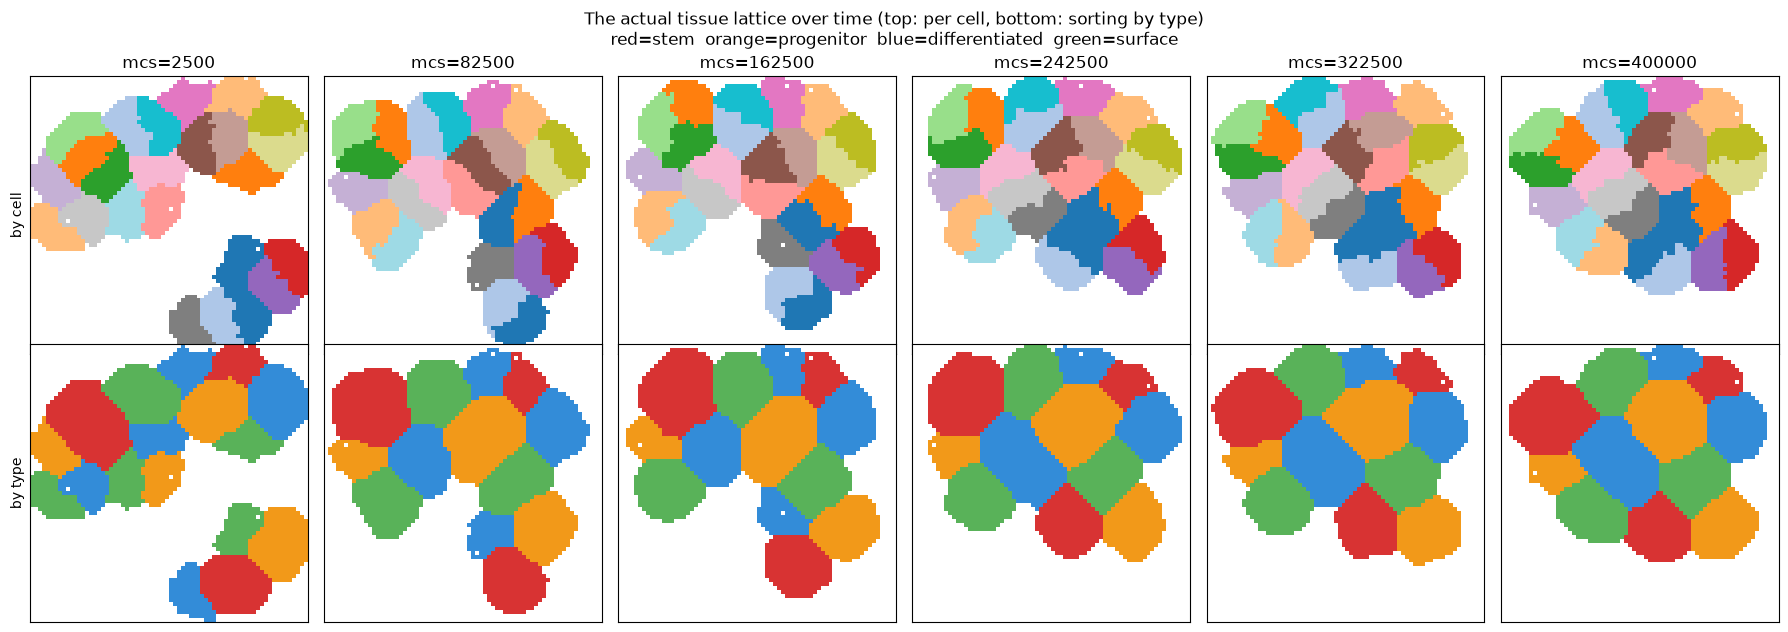

In [6]:
n = len(result.samples)
frame_indices = sorted(set([0, n // 5, 2 * n // 5, 3 * n // 5, 4 * n // 5, n - 1]))

fig, axes = plt.subplots(2, len(frame_indices), figsize=(3 * len(frame_indices), 6.4))
for col, i in enumerate(frame_indices):
    lattice = result.samples[i].lattice
    axes[0, col].imshow(render_by_cell(lattice), interpolation="nearest")
    axes[0, col].set_title(f"mcs={result.samples[i].mcs}")
    axes[1, col].imshow(render_by_type(lattice), interpolation="nearest")
    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([])
        ax.set_yticks([])

axes[0, 0].set_ylabel("by cell")
axes[1, 0].set_ylabel("by type")
fig.suptitle(
    "The actual tissue lattice over time (top: per cell, bottom: sorting by type)\n"
    "red=stem  orange=progenitor  blue=differentiated  green=surface"
)
plt.tight_layout()
plt.show()

## Animate it

Renders every captured frame as a looping animation of the real lattice. In
JupyterLab/Jupyter Notebook this displays inline; if `to_jshtml` is slow or
unsupported in your environment, `anim.save("organoid.gif")` (needs
`pillow`, already a dev dependency here) is a reliable fallback.

In [7]:
from IPython.display import HTML
from matplotlib import animation

fig, (ax_cell, ax_type) = plt.subplots(1, 2, figsize=(9, 4.5))
im_cell = ax_cell.imshow(render_by_cell(result.samples[0].lattice), interpolation="nearest")
im_type = ax_type.imshow(render_by_type(result.samples[0].lattice), interpolation="nearest")
ax_cell.set_title("by cell")
ax_type.set_title("by type")
for ax in (ax_cell, ax_type):
    ax.set_xticks([])
    ax.set_yticks([])
title = fig.suptitle(f"mcs={result.samples[0].mcs}")


def update(i):
    sample = result.samples[i]
    im_cell.set_data(render_by_cell(sample.lattice))
    im_type.set_data(render_by_type(sample.lattice))
    title.set_text(f"mcs={sample.mcs}")
    return [im_cell, im_type, title]


anim = animation.FuncAnimation(fig, update, frames=len(result.samples), interval=300)
plt.close(fig)
HTML(anim.to_jshtml())

## Notes & Limitations

This is the actual lattice. Every pixel represents a real site ID rather than a simplified schematic, so you can clearly see cell shapes, stretching, and local interactions.

* Four-way sorting vs. nested layers: This run produces a four-way sort where each cell type clusters with itself. Real organoids often show a nested structure (e.g., stem cells on the inside, differentiated cells on the outside). If you want to encourage nested layering, set J[type][medium] so it increases monotonically from the inside type to the outside type. Plan for longer runs, as nested sorting takes much more time to settle.

* Membrane jiggle is normal: Cells will continue to fluctuate along their edges even after reaching a steady state. This mimics real membrane dynamics under finite temperature. Track the homotypic contact fraction to verify structural convergence rather than waiting for pixels to stop moving entirely.

* Readout timing: The simulator only returns samples captured during the readout window. While real inference runs use burn_in_mcs to discard the initial relaxation phase, keeping it at 0 lets you see the whole process from the start.

* Visualization cost: Setting include_lattice=True copies the entire grid at every sample point. It is great for visual checks, but production pipelines should leave it off and rely on the lighter summary fields in result.samples[i] (like ids, volume, and centroid).